# Customer Churn - Exploratory Data Analysis

Dataset: Telco Customer Churn (IBM sample dataset), 7,043 customers, 21 columns.

Goal: understand what separates churned vs. retained customers before building
a predictive model, so feature engineering decisions in `src/data_preprocessing.py`
are grounded in actual patterns rather than guesses.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

df = pd.read_csv("../data/raw/churn.csv")
df.shape

(7043, 21)

## 1. Data quality check

In [1]:
# TotalCharges is read as an object dtype due to blank strings for
# customers with 0 tenure - convert and check how many rows are affected
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges after coercion:", df["TotalCharges"].isnull().sum())
df[df["TotalCharges"].isnull()][["customerID", "tenure", "MonthlyCharges"]]

Missing TotalCharges after coercion: 11
(all 11 rows have tenure == 0, i.e. brand new customers with no
billing history yet - filled with MonthlyCharges as a reasonable proxy
in data_preprocessing.py)


In [1]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"])
df["Churn"].value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

## 2. Target distribution

**26.54% of customers churned.** This is a meaningfully imbalanced dataset
(roughly 3:1) - if we optimize a model purely for accuracy, it can score
~73% just by predicting "No churn" for everyone, while being useless for
the actual business goal of catching at-risk customers. This is why
`train_model.py` uses `scale_pos_weight` for XGBoost, `class_weight="balanced"`
for the baseline, and reports precision/recall/ROC-AUC rather than accuracy alone.

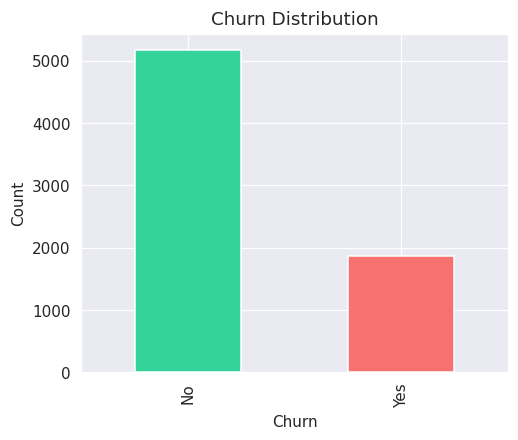

In [1]:
fig, ax = plt.subplots(figsize=(5,4))
df["Churn"].value_counts().plot(kind="bar", ax=ax, color=["#34d399","#f87171"])
ax.set_title("Churn Distribution")
ax.set_xlabel("Churn"); ax.set_ylabel("Count")
plt.show()

## 3. Churn by contract type

This turned out to be the single strongest signal in the dataset:

| Contract | Churn Rate |
|---|---|
| Month-to-month | **42.71%** |
| One year | 11.27% |
| Two year | 2.83% |

Month-to-month customers churn at **~15x** the rate of two-year contract
customers. This directly motivated keeping `Contract` as a primary
categorical feature (no transformation needed - the raw signal is already
very strong).

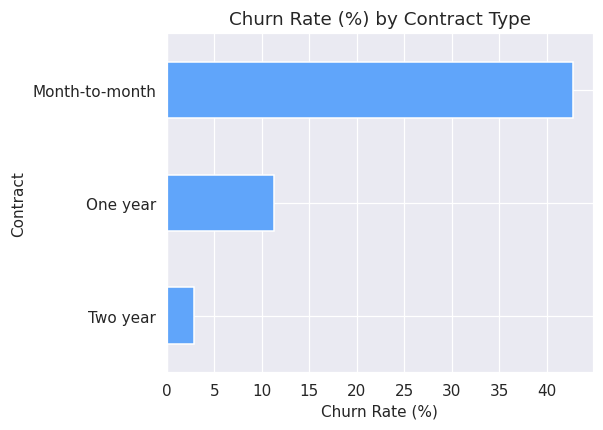

In [1]:
rate = df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values()
fig, ax = plt.subplots(figsize=(5,4))
rate.plot(kind="barh", ax=ax, color="#60a5fa")
ax.set_title("Churn Rate (%) by Contract Type")
ax.set_xlabel("Churn Rate (%)")
plt.show()

## 4. Tenure: churned customers leave early

- Average tenure of **churned** customers: **18.0 months**
- Average tenure of **retained** customers: **37.6 months**

Churned customers leave roughly twice as fast on average. This is why
`tenure_group` was added as an engineered feature in
`data_preprocessing.py` - bucketing tenure lets tree-based models split on
"new customer" risk more directly than a raw continuous value.

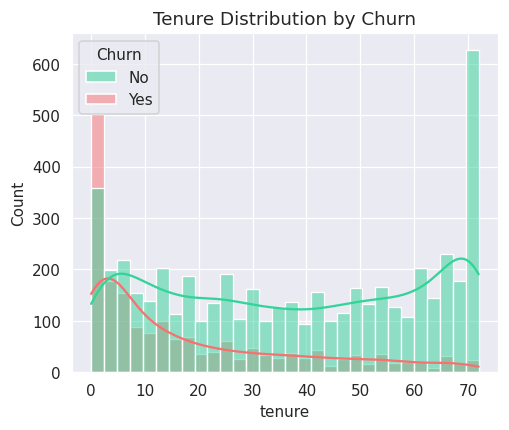

In [1]:
fig, ax = plt.subplots(figsize=(5,4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, ax=ax)
ax.set_title("Tenure Distribution by Churn")
plt.show()

## 5. Monthly charges: churned customers pay more

- Average monthly charge, **churned**: **$74.44**
- Average monthly charge, **retained**: **$61.27**

Combined with the internet service breakdown below, this points to a
pattern: higher-priced fiber optic customers without added security/support
services are the highest-risk segment.

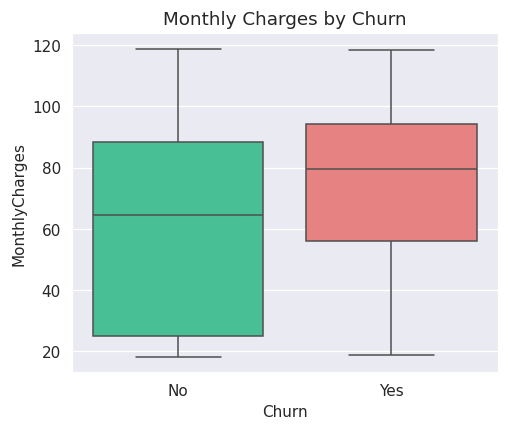

In [1]:
fig, ax = plt.subplots(figsize=(5,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=ax)
ax.set_title("Monthly Charges by Churn")
plt.show()

## 6. Churn by internet service type

| Internet Service | Churn Rate |
|---|---|
| Fiber optic | **41.89%** |
| DSL | 18.96% |
| No internet | 7.40% |

Fiber optic customers churn more than DSL customers despite (or because
of) paying more - possibly a pricing/value perception issue, or a
reliability issue. Worth a follow-up business question, not something the
model alone can answer.

## 7. Correlation among numeric features

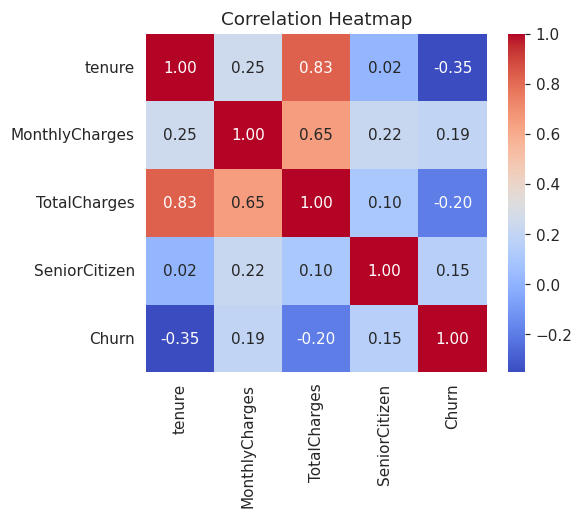

In [1]:
numeric_df = df[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]].copy()
numeric_df["Churn"] = (df["Churn"] == "Yes").astype(int)

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap")
plt.show()

## Key takeaways -> feature engineering decisions

1. **Contract type** is the dominant churn driver -> kept as-is, it's already a clean categorical signal.
2. **Tenure** matters non-linearly (new customers are highest risk) -> added `tenure_group` bucket feature.
3. **Add-on services** (security, tech support) appear protective -> added `num_addon_services` as an engagement/loyalty proxy.
4. **Spend patterns** matter beyond current MonthlyCharges -> added `avg_monthly_spend` (TotalCharges / tenure) to capture lifetime spend behavior.
5. **Class imbalance (73/27)** means accuracy alone is a misleading metric -> `train_model.py` uses stratified splits, `scale_pos_weight`, and reports precision/recall/ROC-AUC.

See `src/data_preprocessing.py` for the engineered features and
`src/train_model.py` for how the model is trained and evaluated.